In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import json
import os
import re
from unidecode import unidecode
from tqdm import tqdm
from catboost import CatBoostClassifier, Pool
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(device)

mps


In [2]:
df_clean = pd.read_csv("./datasets/rank_dataset_TRAIN_CATBOOST.csv")
with open('../gym_model/vocab.json', 'r') as f:
    vocab = json.load(f)
id2name = {v: k for k, v in vocab.items()}
df_clean.head()

,bert_score,candidate_id,is_same_group,target,eq_clean,level_idx,goal_clean
0,0.001278,1546,0,0,Machine,3,Powerbuilding
1,0.001276,1440,0,0,Machine,0,Bodybuilding
2,0.001778,2733,0,0,Machine,0,Athletics
3,0.001300,2731,0,0,Dumbbell,0,Athletics
4,0.001246,1075,0,0,Barbell,1,Athletics


In [3]:
class TransformerRec(nn.Module):
    def __init__(self, vocab_size, hidden=256, heads=8, layers=4, max_len=20, dropout=0.2):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, hidden)
        self.pos_emb = nn.Embedding(max_len, hidden)
        self.dropout = nn.Dropout(dropout)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden, 
            nhead=heads, 
            dropout=dropout, 
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=layers)
        
        self.fc = nn.Linear(hidden, vocab_size)

    def forward(self, x):
        positions = torch.arange(x.size(1), device=x.device).unsqueeze(0)
        x = self.dropout(self.token_emb(x) + self.pos_emb(positions))
        x = self.transformer(x)
        return self.fc(x)
    
model = TransformerRec(vocab_size=len(vocab)).to(device)

checkpoint_path = '../gym_bert_data/checkpoints-2/best_model.pth' 
if os.path.exists(checkpoint_path):
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model.eval()

TransformerRec(
  (token_emb): Embedding(3058, 256)
  (pos_emb): Embedding(20, 256)
  (dropout): Dropout(p=0.2, inplace=False)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (linear1): Linear(in_features=256, out_features=2048, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=2048, out_features=256, bias=True)
        (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.2, inplace=False)
        (dropout2): Dropout(p=0.2, inplace=False)
      )
    )
  )
  (fc): Linear(in_features=256, out_features=3058, bias=True)
)

In [4]:
nan_count = df_clean['eq_clean'].isna().sum()
print(f"Пустых значений (NaN): {nan_count}")

print("\n--- Распределение по категориям ---")
dist = df_clean['eq_clean'].value_counts(dropna=False)
print(dist)

labeled_count = dist.drop(['unlabeled', 'REVIEW_NEEDED'], errors='ignore').sum()
total_rows = len(df_clean)
percent = (labeled_count / total_rows) * 100
print(f"\nРазмечено для обучения: {labeled_count} строк ({percent:.4f}%)")

if 'REVIEW_NEEDED' in dist.index:
    print("\n⚠️ ВНИМАНИЕ: У вас остались значения 'REVIEW_NEEDED'.")
    print("Их нужно либо заменить на 'unlabeled', либо доразметить.")

Пустых значений (NaN): 0

--- Распределение по категориям ---
eq_clean
Machine       16739
Bodyweight    12719
Dumbbell       8003
Barbell        7778
Name: count, dtype: int64

Размечено для обучения: 45239 строк (100.0000%)


In [5]:
cat_features = ['candidate_id', 'eq_clean', 'goal_clean']
for col in cat_features:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna('Unknown').astype(str)

X = df_clean.drop('target', axis=1)
y = df_clean['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)
cat_features_indices = [X_train.columns.get_loc(col) for col in cat_features if col in X_train.columns]

model = CatBoostClassifier(
    iterations=5000,
    learning_rate=0.07,
    depth=8,
    cat_features=cat_features_indices,
    eval_metric='F1',
    auto_class_weights='Balanced',
    random_seed=42,
    early_stopping_rounds=100,
    verbose=100
)

model.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    use_best_model=True
)

0:	learn: 0.9203391	test: 0.9348522	best: 0.9348522 (0)	total: 69.3ms	remaining: 5m 46s
100:	learn: 0.9372104	test: 0.9491644	best: 0.9491644 (98)	total: 773ms	remaining: 37.5s
200:	learn: 0.9590044	test: 0.9587655	best: 0.9588993 (180)	total: 1.62s	remaining: 38.7s
300:	learn: 0.9699837	test: 0.9667629	best: 0.9677897 (286)	total: 2.58s	remaining: 40.3s
400:	learn: 0.9782594	test: 0.9694230	best: 0.9694230 (397)	total: 3.56s	remaining: 40.8s
500:	learn: 0.9826306	test: 0.9701558	best: 0.9718719 (492)	total: 4.54s	remaining: 40.8s
600:	learn: 0.9849759	test: 0.9727838	best: 0.9736963 (595)	total: 5.53s	remaining: 40.5s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.973696346
bestIteration = 595

Shrink model to first 596 iterations.


CatBoostClassifier(auto_class_weights='Balanced', cat_features=[1, 3, 5], depth=8, early_stopping_rounds=100, eval_metric='F1', iterations=5000, learning_rate=0.07, random_seed=42, verbose=100)

🏆 Лучший результат (F1 Score): 0.9737


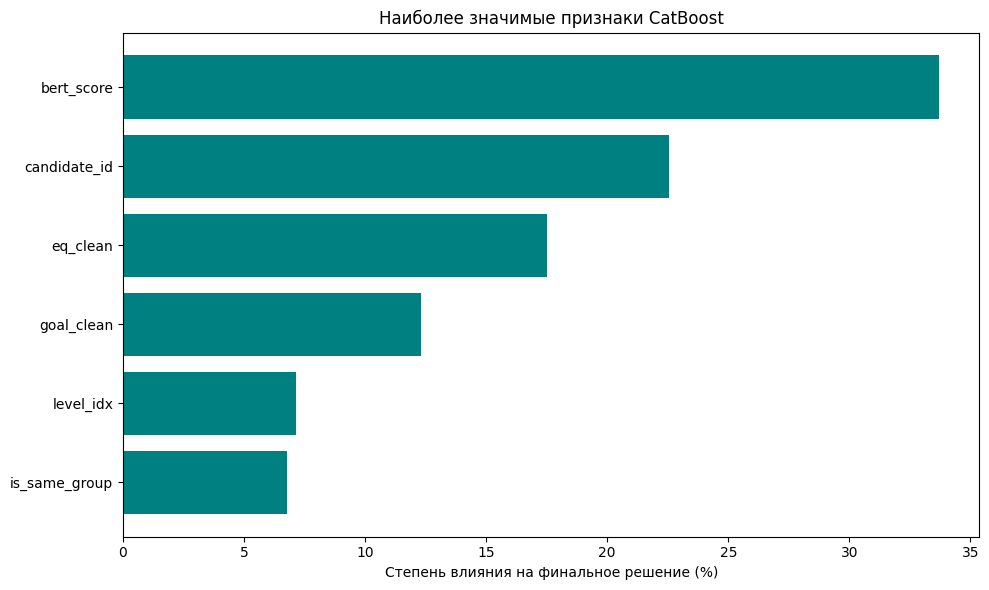

In [6]:
print(f"🏆 Лучший результат (F1 Score): {model.best_score_['validation']['F1']:.4f}")

feature_importance = model.get_feature_importance()
sorted_idx = feature_importance.argsort()

plt.figure(figsize=(10, 6))
plt.barh(X_train.columns[sorted_idx], feature_importance[sorted_idx], color='teal')
plt.xlabel("Степень влияния на финальное решение (%)")
plt.title("Наиболее значимые признаки CatBoost")
plt.tight_layout()
plt.show()


model.save_model("../gym_model/catboost_recommender_final.cbm")